## 1. A Consumer with two nests

In [5]:
from types import SimpleNamespace
import numpy as np
from scipy import optimize


from Consumer import ConsumerClass



#Find results
consumer=ConsumerClass()
opt = consumer.solve()


print("Results using L-BFGS-B:")
#Print shares spend on each item
print(f'Food share (s1):       {opt.s1:.4f}')
print(f'Bus share (s2):        {opt.s2:.4f}')
print(f'Train share (s3):      {opt.s3:.4f}')

#Check shares = 1
print(f'Share sum :            {opt.s1 + opt.s2 + opt.s3:.2f}')

#Print quantities
x1, x2, x3 = consumer.quantities(opt.s1, opt.w)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Bus quantity (x2):     {x2:.4f}')
print(f'Train quantity (x3):   {x3:.4f}')

print("Optimizer succeeded:  ", opt.res.success)

#Print final utility
print(f'Utility:               {opt.u:.4f}')

print("Results using grid:")

opt_grid = consumer.solve_grid()

#Print shares spend on each item
print(f'Food share (s1):       {opt_grid.s1:.4f}')
print(f'Bus share (s2):        {opt_grid.s2:.4f}')
print(f'Train share (s3):      {opt_grid.s3:.4f}')

#Check shares = 1
print(f'Share sum :            {opt_grid.s1 + opt_grid.s2 + opt_grid.s3:.2f}')

#Print quantities
x1, x2, x3 = consumer.quantities(opt_grid.s1, opt_grid.w)

print(f'Food quantity (x1):    {x1:.4f}')
print(f'Bus quantity (x2):     {x2:.4f}')
print(f'Train quantity (x3):   {x3:.4f}')

#Print utility 
print(f'Utility:               {opt_grid.u:.4f}')

print(opt.res.success)
print(opt.res.message)



Results using L-BFGS-B:
Food share (s1):       0.5356
Bus share (s2):        0.2041
Train share (s3):      0.2603
Share sum :            1.00
Food quantity (x1):    5.3562
Bus quantity (x2):     2.0408
Train quantity (x3):   1.7353
Optimizer succeeded:   True
Utility:               3.4017
Results using grid:
Food share (s1):       0.5377
Bus share (s2):        0.2021
Train share (s3):      0.2602
Share sum :            1.00
Food quantity (x1):    5.3769
Bus quantity (x2):     2.0212
Train quantity (x3):   1.7346
Utility:               3.4016
True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


The results for the L-BFGS-B and grid method are very similar, which seemingly should lead us to believe that the methods are done correctly. Both methods result in only positive quantities, and the quantity shares equal 1, once again indicating that the answer is possible.

## 2 Solving the model numerically

2.2 L-BFGS-B

In [6]:
#Compare methods
print(opt.s1, opt.w, opt.u)
print(opt.res.nfev)  #function evaluations
print(opt.res.nit)   #iterations
print(opt.res.success)

#Runtime for results
import time

start = time.perf_counter()
opt = consumer.solve()
runtime = time.perf_counter() - start

print(f'Runtime: {runtime:.6f} seconds')


#Convergence path
opt.path



0.5356233806953101 0.43947902810370126 3.401679875985606
18
4
True
Runtime: 0.007812 seconds


array([[0.5       , 0.5       ],
       [0.51661738, 0.48338262],
       [0.5360763 , 0.43575106],
       [0.53560667, 0.43965199],
       [0.53562338, 0.43947903]])

## 3 Relative prices and demand
**3.1**

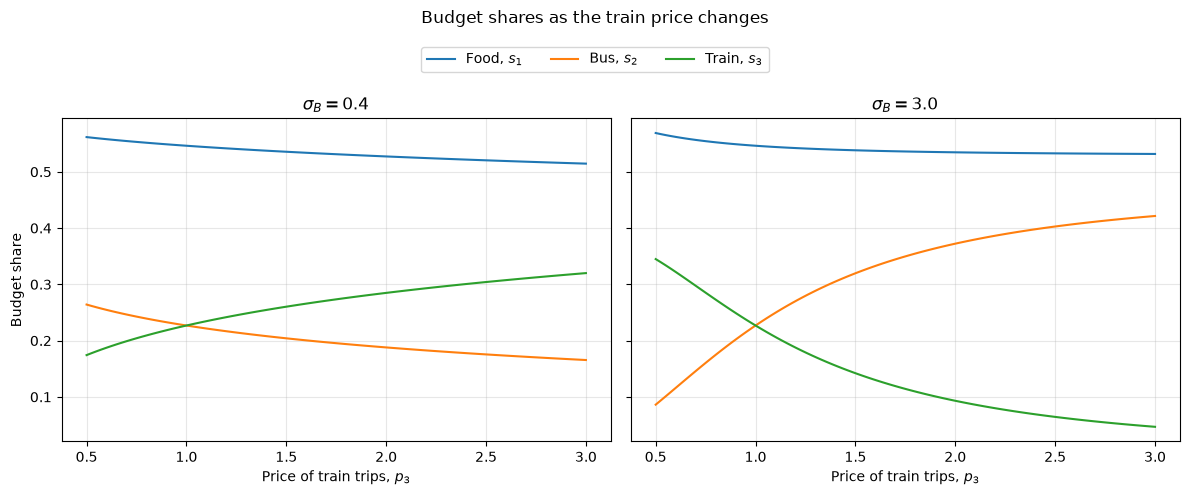

In [16]:
import matplotlib.pyplot as plt

p3_values = np.linspace(0.5, 3.0, 100)
sigma_B_values = (0.4, 3.0)

#Store the results for each calibration.
share_results = {}

for sigma_B in sigma_B_values:
    shares = np.empty((len(p3_values), 3))
    consumer_p = ConsumerClass(par={'sigma_B': sigma_B})
    s0 = None

    for i, p3 in enumerate(p3_values):
        consumer_p.par.p3 = p3
        opt_p = consumer_p.solve(s0=s0, do_print=False)
        shares[i] = [opt_p.s1, opt_p.s2, opt_p.s3]

        # Use the previous solution as the next starting point.
        s0 = np.array([opt_p.s1, opt_p.w])

    share_results[sigma_B] = shares

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, sigma_B in zip(axes, sigma_B_values):
    shares = share_results[sigma_B]
    ax.plot(p3_values, shares[:, 0], label='Food, $s_1$')
    ax.plot(p3_values, shares[:, 1], label='Bus, $s_2$')
    ax.plot(p3_values, shares[:, 2], label='Train, $s_3$')
    ax.set_title(fr'$\sigma_B={sigma_B}$')
    ax.set_xlabel('Price of train trips, $p_3$')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Budget share')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.92))
fig.suptitle('Budget shares as the train price changes')
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()





**3.2**


In the first calibration of the model, where $\sigma_B=0.4$, bus and train are complements, meaning the consumer buys the goods together. Therefore, as $p_3$ increases, the demand for both goods decrease, as the consumer can buy less trains, and in turn, they do not want to spend as much on busses. Although a price increase leads to less overall consumption trains (and busses), the train budget share increases. This is because the price rises faster than the quantity falls, and faster than income changes. 

In the second calibration, where $\sigma_B=3.0$, bus and train are substitutes, meaning the consumer buys one good instead of the other. Therefore, as the train gets more expensive, the consumer switches to using the bus, hence, the train budget share decreases significantly as train prices increase. 




**3.3**

In [23]:
for sigma_B in sigma_B_values:
    consumer_q = ConsumerClass(par={'sigma_B': sigma_B})
    shares = share_results[sigma_B]

    bus_quantities = []

    for p3, share in zip(p3_values, shares):
        consumer_q.par.p3 = p3

        s1, s2, s3 = share
        w = s2 / (s2 + s3)  # Conditional bus share within travel

        x1, x2, x3 = consumer_q.quantities(s1, w)
        bus_quantities.append(x2)

    change = bus_quantities[-1] - bus_quantities[0]

    print(f"sigma_B = {sigma_B}")
    print(f"Bus quantity at p3 = {p3_values[0]:.1f}: {bus_quantities[0]:.3f}")
    print(f"Bus quantity at p3 = {p3_values[-1]:.1f}: {bus_quantities[-1]:.3f}")
    print(f"Change in bus-trip quantity: {change:.3f}")
    print()

sigma_B = 0.4
Bus quantity at p3 = 0.5: 2.641
Bus quantity at p3 = 3.0: 1.655
Change in bus-trip quantity: -0.986

sigma_B = 3.0
Bus quantity at p3 = 0.5: 0.862
Bus quantity at p3 = 3.0: 4.215
Change in bus-trip quantity: 3.353





In the first calibration, the number of bus trips the consumer takes decreases. In contrast, the number of bus trips increases in the second calibration. This follows what we would expect based on whether or not bus and train trips are complements or substitutes; for complements, as one good increases in price, the optimal quantity of the compliment good decreases, while the optimal quantity increases for substitutes.

The increase from being substitutes is larger than the decrease from being complements. This is due to the degree of substitution and complementing. 


**3.4**

In [ ]:
for sigma_B in sigma_B_values:
    consumer_food = ConsumerClass(par={'sigma_B': sigma_B})
    food_quantities = []

    for p3, share in zip(p3_values, share_results[sigma_B]):
        consumer_food.par.p3 = p3

        s1, s2, s3 = share
        w = s2 / (s2 + s3)

        x1, _, _ = consumer_food.quantities(s1, w)
        food_quantities.append(x1)

    change = food_quantities[-1] - food_quantities[0]

    print(f"sigma_B = {sigma_B}")
    print(f"Food quantity at p3 = {p3_values[0]:.1f}: {food_quantities[0]:.3f}")
    print(f"Food quantity at p3 = {p3_values[-1]:.1f}: {food_quantities[-1]:.3f}")
    print(f"Change in food quantity: {change:.3f}")
    print()

In both calibrations the budget share for food only decreases slightly (though a little more in the first calibration). Food and travel are complements, meaning this follows the expected outcome. The weight on food is larger than on travel, meaning a larger part of the budget will be reserved for food. 
The effect